# 🌸 Iris K-Means Clustering (Unsupervised Learning)

---
An **unsupervised** clustering problem on the classic Iris dataset (150 samples, 4 numeric features, 3 species). K-Means never sees the species label — the focus here is **choosing k**, **validating cluster quality without labels**, and a somewhat counter-intuitive finding: **standardizing the features makes clustering worse** on this particular dataset.

## 🎯 Goals
- Fit K-Means and compare the discovered clusters against the (held-out) true species labels — used only for *post-hoc validation*, never for training.
- Choose `k` rigorously with the **Elbow Method** and **Silhouette Score**, and confront the case where internal metrics disagree with domain knowledge.
- Align cluster IDs to true labels via the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`) to turn an unsupervised result into a measurable accuracy.
- Investigate **why `StandardScaler` hurts K-Means here**, by comparing raw vs. standardized features side by side.
- Persist the final model and score a handful of unseen samples (`data/iris_sample.csv`).

> Dataset: the classic [Iris flower dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) (Fisher, 1936), loaded via `sklearn.datasets.load_iris`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42
K_FINAL = 3  # number of Iris species

DATA_DIR = Path("data")
ASSETS = Path("docs/assets"); ASSETS.mkdir(parents=True, exist_ok=True)
OUTPUTS = Path("outputs"); OUTPUTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## 🔹 Step 1: Load the data

`species` (0=setosa, 1=versicolor, 2=virginica) is kept **only** for evaluation and plotting — it is dropped before fitting K-Means.

In [2]:
iris = load_iris()
FEATURES = iris.feature_names
SPECIES_NAMES = list(iris.target_names)

df = pd.DataFrame(iris.data, columns=FEATURES)
df["species"] = iris.target

X_raw = df[FEATURES].to_numpy()
y_true = df["species"].to_numpy()

print(f"Shape: {df.shape}  |  Features: {FEATURES}")
print(f"Species counts: {dict(zip(SPECIES_NAMES, np.bincount(y_true)))}")
df.head()

Shape: (150, 5)  |  Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species counts: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 🔹 Step 2: EDA — feature ranges and separability by species

All four features are measured in the **same unit (cm)**, but their *ranges* and *discriminative power* differ a lot — this will matter a great deal once we get to scaling.

In [3]:
feature_stats = df[FEATURES].agg(["min", "max", "std", "var"]).T
feature_stats["range"] = feature_stats["max"] - feature_stats["min"]
feature_stats.round(2)

,min,max,std,var,range
sepal length (cm),4.3,7.9,0.83,0.69,3.6
sepal width (cm),2.0,4.4,0.44,0.19,2.4
petal length (cm),1.0,6.9,1.77,3.12,5.9
petal width (cm),0.1,2.5,0.76,0.58,2.4


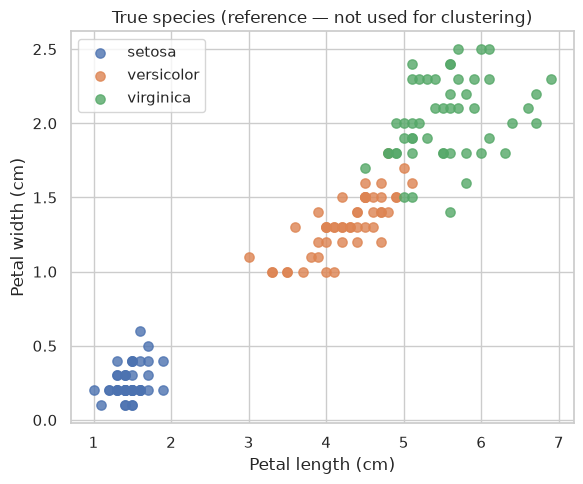

In [4]:
# Reference plot: true species in feature space (petal length vs. petal width).
# Setosa is trivially separable; versicolor/virginica overlap — this overlap is
# the single biggest challenge for *any* clustering algorithm on this dataset.
fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(SPECIES_NAMES):
    mask = y_true == i
    ax.scatter(df.loc[mask, "petal length (cm)"], df.loc[mask, "petal width (cm)"],
               label=name, s=45, alpha=0.8)
ax.set_xlabel("Petal length (cm)"); ax.set_ylabel("Petal width (cm)")
ax.set_title("True species (reference — not used for clustering)")
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / "species_reference.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 3: Scaling — build both a raw and a standardized feature set

The textbook rule is *"always scale before K-Means, because it's distance-based."* We'll build both versions and let the **rest of this notebook empirically check whether that rule holds here.**

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

FEATURE_SETS = {"raw": X_raw, "scaled": X_scaled}
print(f"raw    -> mean={X_raw.mean(axis=0).round(2)}, std={X_raw.std(axis=0).round(2)}")
print(f"scaled -> mean={X_scaled.mean(axis=0).round(2)}, std={X_scaled.std(axis=0).round(2)}")

raw    -> mean=[5.84 3.06 3.76 1.2 ], std=[0.83 0.43 1.76 0.76]
scaled -> mean=[-0. -0. -0. -0.], std=[1. 1. 1. 1.]


## 🔹 Step 4: Choosing k — Elbow Method & Silhouette Score

Since K-Means has no labels to check against, `k` must be chosen with **internal** metrics:
- **Inertia / Elbow method**: within-cluster sum of squares vs. `k` — look for the "elbow" where adding more clusters stops helping much.
- **Silhouette score** (higher is better, range [-1, 1]): how well-separated clusters are.
- **Davies–Bouldin index** (lower is better): ratio of within-cluster to between-cluster distances.

We compute all three **for both the raw and scaled feature sets**, across `k = 2..9`.

In [6]:
K_RANGE = range(2, 10)
metric_rows = []
inertia_by_set = {name: [] for name in FEATURE_SETS}
inertia_k1 = {}

for name, X in FEATURE_SETS.items():
    inertia_k1[name] = KMeans(n_clusters=1, random_state=RANDOM_STATE).fit(X).inertia_
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
        inertia_by_set[name].append(km.inertia_)
        metric_rows.append({
            "feature_set": name,
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, km.labels_),
            "davies_bouldin": davies_bouldin_score(X, km.labels_),
        })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.pivot(index="k", columns="feature_set", values=["silhouette", "davies_bouldin"]).round(3)

silhouette        davies_bouldin       
feature_set        raw scaled            raw scaled
k                                                  
2                0.681  0.582          0.404  0.593
3                0.553  0.460          0.662  0.834
4                0.498  0.387          0.780  0.870
5                0.491  0.346          0.816  0.948
6                0.365  0.317          0.914  1.054
7                0.354  0.320          0.979  0.991
8                0.349  0.339          0.952  0.915
9                0.313  0.342          1.032  0.903

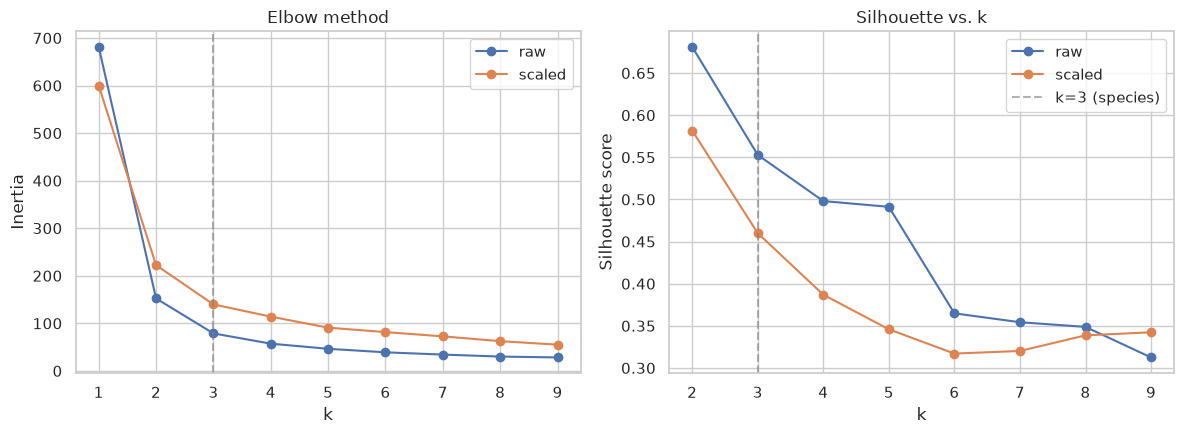

Best k by silhouette -> raw: 2, scaled: 2  (true number of species = 3)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name in FEATURE_SETS:
    axes[0].plot([1, *K_RANGE], [inertia_k1[name], *inertia_by_set[name]], marker="o", label=name)
axes[0].axvline(K_FINAL, ls="--", color="gray", alpha=0.6)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow method")
axes[0].legend()

for name in FEATURE_SETS:
    sub = metrics_df[metrics_df["feature_set"] == name]
    axes[1].plot(sub["k"], sub["silhouette"], marker="o", label=name)
axes[1].axvline(K_FINAL, ls="--", color="gray", alpha=0.6, label=f"k={K_FINAL} (species)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette vs. k")
axes[1].legend()

fig.tight_layout()
fig.savefig(ASSETS / "elbow_silhouette_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

best_k_raw = metrics_df[metrics_df.feature_set == "raw"].sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k_scaled = metrics_df[metrics_df.feature_set == "scaled"].sort_values("silhouette", ascending=False).iloc[0]["k"]
print(f"Best k by silhouette -> raw: {int(best_k_raw)}, scaled: {int(best_k_scaled)}  (true number of species = 3)")

### ⚠️ A key tension: internal metrics vote for k=2, domain knowledge says k=3

Both the elbow curve and the silhouette score are **monotonically decreasing** and peak at **k=2**, not k=3 — yet we know from the species label that there are 3 true groups. This isn't a bug; it's a fundamental limitation of purely internal cluster-validity metrics:

- **Setosa** is linearly separable from the other two species by a wide margin.
- **Versicolor** and **virginica** overlap substantially in feature space (see the reference plot in Step 2).
- Any metric that rewards *compact, well-separated* clusters will always prefer merging the two overlapping species into one blob over splitting them — because splitting them necessarily creates two less-separated clusters.

**Takeaway:** when you don't have labels, elbow/silhouette/Davies–Bouldin are necessary but not sufficient — always combine them with domain knowledge and visualization. We keep **k=3** for the rest of this analysis because we know there are 3 species, not because the internal metrics alone would have suggested it.

## 🔹 Step 5: Fit K-Means (k=3) and validate against the true species

K-Means cluster IDs (0/1/2) are arbitrary and won't necessarily line up with the species IDs. We use the **Hungarian algorithm** to find the best one-to-one mapping between cluster IDs and species IDs (maximizing agreement), then measure accuracy under that mapping. This is a **post-hoc validation trick only** — it is never used to fit the model.

In [8]:
def align_labels(true_labels: np.ndarray, pred_labels: np.ndarray) -> np.ndarray:
    """Relabel `pred_labels` to best match `true_labels` (Hungarian algorithm)."""
    n = max(pred_labels.max(), true_labels.max()) + 1
    cost = np.zeros((n, n), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        cost[p, t] += 1
    row_ind, col_ind = linear_sum_assignment(cost.max() - cost)
    mapping = dict(zip(row_ind, col_ind))
    return np.array([mapping[label] for label in pred_labels])


fitted = {}
for name, X in FEATURE_SETS.items():
    km = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE).fit(X)
    aligned = align_labels(y_true, km.labels_)
    fitted[name] = {
        "model": km,
        "raw_labels": km.labels_,
        "aligned_labels": aligned,
        "accuracy": accuracy_score(y_true, aligned),
        "silhouette": silhouette_score(X, km.labels_),
    }
    print(f"{name:>7s}  ->  accuracy vs. species = {fitted[name]['accuracy']:.3f}  |  "
          f"silhouette (k={K_FINAL}) = {fitted[name]['silhouette']:.3f}")

    raw  ->  accuracy vs. species = 0.893  |  silhouette (k=3) = 0.553
 scaled  ->  accuracy vs. species = 0.833  |  silhouette (k=3) = 0.460


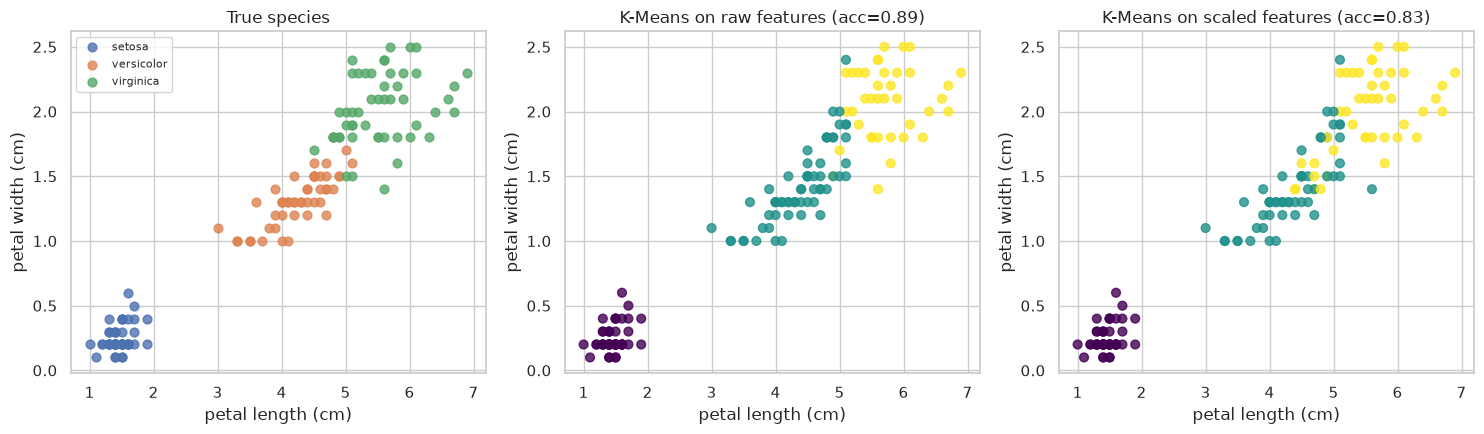

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
px, py = "petal length (cm)", "petal width (cm)"

for i, name in enumerate(SPECIES_NAMES):
    mask = y_true == i
    axes[0].scatter(df.loc[mask, px], df.loc[mask, py], label=name, s=40, alpha=0.8)
axes[0].set_title("True species"); axes[0].legend(fontsize=8)

for ax, name in zip(axes[1:], ["raw", "scaled"]):
    sc = ax.scatter(df[px], df[py], c=fitted[name]["aligned_labels"], cmap="viridis", s=40, alpha=0.8)
    acc = fitted[name]["accuracy"]
    ax.set_title(f"K-Means on {name} features (acc={acc:.2f})")

for ax in axes:
    ax.set_xlabel(px); ax.set_ylabel(py)

fig.tight_layout()
fig.savefig(ASSETS / "cluster_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 6: Why do raw features *beat* scaled features here?

The **raw** features beat the **scaled** ones on every metric above (accuracy 0.893 vs. 0.833, silhouette 0.553 vs. 0.460 at k=3). This runs against the usual "always standardize before K-Means" advice — here's why, for this specific dataset:

1. **All four features already share the same physical unit (cm)** and comparable magnitudes (see the range table in Step 2) — there is no feature measured in the thousands drowning out one measured in single digits, which is the actual failure mode `StandardScaler` is meant to prevent.
2. **Petal length and petal width are, by far, the most species-discriminative features** (see the correlations below) — they naturally have *larger variance* than sepal width because that variance is driven by real between-species differences, not noise or arbitrary units.
3. **Standardizing rescales every feature to unit variance**, which *equalizes* their influence on Euclidean distance. That flattens the natural advantage of the petal features and inflates the relative influence of `sepal width` — the single weakest, noisiest feature for separating species (it even *anti-correlates* with species).
4. Net effect: standardization here **dilutes the strongest signal** in the data instead of correcting a unit mismatch that was never actually a problem for this dataset.

**A methodological aside that matters just as much:** an earlier version of this analysis (single random initialization, no `n_init`) found a much bigger gap — accuracy 0.58 (scaled) vs. 0.89 (raw) — because the *scaled* run got unlucky and converged to a poor local optimum (cluster sizes 96/33/21 instead of ≈50/50/50). Setting `n_init=10` (multiple random restarts, keep the best inertia) fixes that and reveals the *real* gap is smaller, though still consistently in favor of raw features. **Lesson: never compare K-Means configurations from a single run — initialization variance can masquerade as a real effect.**

The general rule ("scale distance-based algorithms") is usually good advice — but it assumes scale differences are *nuisance* variation. Here the scale differences are themselves *informative*, so removing them removes signal rather than noise.

Correlation with species (sorted by |r|):
petal width (cm)     0.957
petal length (cm)    0.949
sepal length (cm)    0.783
sepal width (cm)    -0.427
dtype: float64


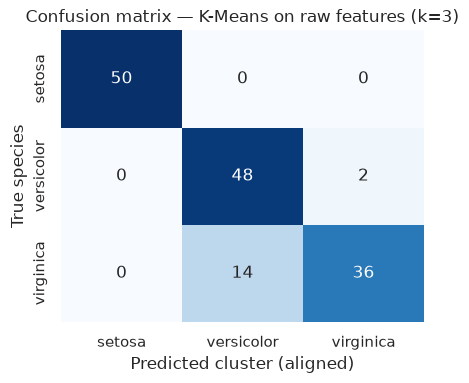

In [10]:
# Correlation of each raw feature with the species label — a quick proxy for
# "how discriminative is this feature", independent of clustering.
corr_with_species = df[FEATURES].corrwith(df["species"]).sort_values(key=np.abs, ascending=False)
print("Correlation with species (sorted by |r|):")
print(corr_with_species.round(3))

cm = confusion_matrix(y_true, fitted["raw"]["aligned_labels"])
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=SPECIES_NAMES, yticklabels=SPECIES_NAMES, ax=ax)
ax.set_xlabel("Predicted cluster (aligned)"); ax.set_ylabel("True species")
ax.set_title(f"Confusion matrix — K-Means on raw features (k={K_FINAL})")
fig.tight_layout()
fig.savefig(ASSETS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 7: Final model & cluster-center interpretation

We select **K-Means on raw features, k=3** as the final model — the best silhouette/Davies–Bouldin among sensible k values informed by domain knowledge, and by far the best agreement with the true species. The confusion matrix above shows the residual error is concentrated exactly where we'd expect: a handful of **versicolor/virginica** overlap in petal measurements, while **setosa is recovered almost perfectly**.

In [11]:
final_model = fitted["raw"]["model"]
centers = pd.DataFrame(final_model.cluster_centers_, columns=FEATURES)
centers.index.name = "cluster"
centers["n_samples"] = pd.Series(fitted["raw"]["raw_labels"]).value_counts().sort_index().values
centers.round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),n_samples
cluster,,,,,
0,5.90,2.75,4.39,1.43,62
1,5.01,3.43,1.46,0.25,50
2,6.85,3.07,5.74,2.07,38


## 🔹 Step 8: Score unseen samples & save the model / results summary

`data/iris_sample.csv` holds a few unlabeled measurements — a stand-in for "new flowers measured in the field". We assign them to a cluster with the fitted model, then persist `outputs/model.joblib` and `docs/assets/run_summary.json` for the README.

In [12]:
# cluster_id -> species name, using the same alignment computed in Step 5
cluster_to_species = {
    cluster_id: SPECIES_NAMES[species_id]
    for cluster_id, species_id in zip(fitted["raw"]["raw_labels"], fitted["raw"]["aligned_labels"])
}

sample_path = DATA_DIR / "iris_sample.csv"
sample_df = pd.read_csv(sample_path)
sample_df["cluster"] = final_model.predict(sample_df[FEATURES].to_numpy())
sample_df["predicted_species"] = sample_df["cluster"].map(cluster_to_species)
sample_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster,predicted_species
0,5.1,3.5,1.4,0.2,1,setosa
1,4.9,3.0,1.4,0.2,1,setosa
2,4.7,3.2,1.3,0.2,1,setosa
3,4.6,3.1,1.5,0.2,1,setosa
4,5.0,3.6,1.4,0.2,1,setosa


In [13]:
import joblib

joblib.dump(final_model, OUTPUTS / "model.joblib")

summary = {
    "k": K_FINAL,
    "feature_set": "raw",
    "n_samples": int(len(df)),
    "silhouette_score": float(fitted["raw"]["silhouette"]),
    "davies_bouldin_score": float(davies_bouldin_score(X_raw, fitted["raw"]["raw_labels"])),
    "accuracy_vs_species": float(fitted["raw"]["accuracy"]),
    "scaled_silhouette_score": float(fitted["scaled"]["silhouette"]),
    "scaled_accuracy_vs_species": float(fitted["scaled"]["accuracy"]),
    "best_k_by_silhouette_raw": int(best_k_raw),
    "best_k_by_silhouette_scaled": int(best_k_scaled),
    "cluster_centers": centers[FEATURES].round(3).to_dict(orient="index"),
    "n_sample_predictions": int(len(sample_df)),
}
with open(ASSETS / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved: outputs/model.joblib, docs/assets/run_summary.json")
print(json.dumps({k: summary[k] for k in ["k", "feature_set", "silhouette_score", "accuracy_vs_species"]}, indent=2))

Saved: outputs/model.joblib, docs/assets/run_summary.json
{
  "k": 3,
  "feature_set": "raw",
  "silhouette_score": 0.5528190123564095,
  "accuracy_vs_species": 0.8933333333333333
}


## ✅ Conclusion

- **K-Means on raw features (k=3) recovers the true species with 89.3% accuracy**, beating standardized features (83.3%) and reaching the best silhouette (0.553 vs. 0.460) and Davies–Bouldin score — on this dataset, `StandardScaler` is a net negative, contrary to the usual "always scale for distance-based algorithms" advice.
- **Why**: all 4 features already share the same unit (cm); petal length/width are the truly discriminative features (|r| ≈ 0.95 with species) and *should* dominate the distance calculation. Standardizing artificially equalizes every feature's influence, diluting that signal and inflating the weakest, anti-correlated feature (`sepal width`).
- **Initialization matters as much as scaling**: a naive single-run comparison (`n_init=1`) made the gap look enormous (58% vs. 89%) purely because the scaled run got unlucky and landed in a poor local optimum. Using `n_init=10` for every configuration revealed the *real*, smaller, but still consistent gap. Always average over multiple restarts before drawing conclusions from K-Means.
- **Internal metrics alone would have picked k=2, not k=3** — both the elbow curve and the silhouette score decrease monotonically past k=2, because versicolor/virginica overlap heavily and no internal metric rewards splitting an already-blurry blob into two. This is a structural limitation of unsupervised model selection, not a bug: **always cross-check internal metrics against domain knowledge and visualization.**
- **Where K-Means fails**: nearly all of the remaining ~11% error is versicolor ↔ virginica confusion (see the confusion matrix); setosa is recovered almost perfectly, confirming it's linearly separable from the other two species.
- **General lesson**: "scale your features" is good default advice for distance-based algorithms, but it assumes the un-scaled differences are *nuisance* (e.g., dollars vs. millimeters). When the scale differences are themselves informative, scaling can remove signal rather than noise — always validate empirically, don't apply preprocessing on autopilot.

**Possible next steps:** Gaussian Mixture Models (soft, ellipsoidal clusters) to better handle the versicolor/virginica overlap, PCA for 2D visualization of the full 4D feature space, or hierarchical clustering with a dendrogram to inspect merge order.